# CycleGAN: Sketch ↔ Photo Domain Adaptation
### Unpaired Image-to-Image Translation

## Section 1: Environment Setup & Dependencies

In [ ]:
# Install required packages
!pip install -q kaggle Pillow torchmetrics scikit-image gradio matplotlib tqdm
print('Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.3 MB/s eta 0:00:00
Dependencies installed


In [ ]:
import os
import sys
import json
import time
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
from collections import deque
from IPython.display import clear_output, display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchvision.models import inception_v3

# Metrics
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Environment ready')

Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB
Environment ready


## Section 2: Data Preparation

In [ ]:
# ─────────────────────────────────────────────────────────────────
# DATA CONFIGURATION
# ─────────────────────────────────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 4
NUM_WORKERS = 2
N_SAMPLES   = 3000   # samples per domain (adjust for speed)
DATA_DIR    = Path('/content/cyclegan_data')
CKPT_DIR    = Path('/content/checkpoints')
RESULT_DIR  = Path('/content/results')

for d in [DATA_DIR, DATA_DIR/'trainA', DATA_DIR/'trainB',
          DATA_DIR/'testA',  DATA_DIR/'testB',
          CKPT_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Directories created')

Directories created


In [ ]:
# ─────────────────────────────────────────────────────────────────
# OPTION A: Download QuickDraw .npy files (sketches)
# ─────────────────────────────────────────────────────────────────
# We download a few categories. Each .npy file ≈ 30–100 MB

CATEGORIES = ['cat', 'dog', 'car', 'house', 'face']
BASE_URL = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'

npy_dir = DATA_DIR / 'npy'
npy_dir.mkdir(exist_ok=True)

for cat in CATEGORIES:
    url  = BASE_URL + f'{cat}.npy'
    dest = npy_dir / f'{cat}.npy'
    if not dest.exists():
        print(f'  Downloading {cat}...')
        !wget -q "{url}" -O "{dest}"
    else:
        print(f'  {cat}: already cached')

print('QuickDraw files ready')

QuickDraw files ready


In [ ]:
# ─────────────────────────────────────────────────────────────────
# BUILD DOMAIN A  (Sketches from QuickDraw)
# ─────────────────────────────────────────────────────────────────

def npy_to_images(npy_path, out_dir, n, split_ratio=0.8, img_size=128):
    data = np.load(npy_path)          # shape: (N, 784)
    data = data[:n]                    # subset
    n_train = int(len(data) * split_ratio)
    splits  = {'train': data[:n_train], 'test': data[n_train:]}

    for split, arr in splits.items():
        folder = out_dir / split
        folder.mkdir(parents=True, exist_ok=True)
        for i, flat in enumerate(arr):
            img = Image.fromarray(flat.reshape(28, 28).astype(np.uint8), mode='L')
            # Invert (QuickDraw is white-on-black, we want black-on-white)
            img = Image.fromarray(255 - np.array(img))
            img = img.resize((img_size, img_size), Image.BICUBIC)
            img = img.convert('RGB')
            img.save(folder / f'{npy_path.stem}_{i:05d}.png')
    return len(splits['train']), len(splits['test'])

sketch_train_dir = DATA_DIR / 'trainA'
sketch_test_dir  = DATA_DIR / 'testA'

per_cat = N_SAMPLES // len(CATEGORIES)
total_tr = total_te = 0
for cat in CATEGORIES:
    npy_path = npy_dir / f'{cat}.npy'
    tr, te = npy_to_images(npy_path, DATA_DIR / 'A_tmp', per_cat)
    total_tr += tr; total_te += te

# Move to trainA / testA
import shutil
for split_src, split_dst in [('train', sketch_train_dir), ('test', sketch_test_dir)]:
    src = DATA_DIR / 'A_tmp' / split_src
    for f in src.iterdir():
        shutil.copy(f, split_dst / f.name)

print(f'Domain A (Sketches): {len(list(sketch_train_dir.iterdir()))} train | {len(list(sketch_test_dir.iterdir()))} test')

/tmp/ipykernel_6611/3557990670.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(flat.reshape(28, 28).astype(np.uint8), mode='L')


Domain A (Sketches): 2400 train | 600 test


In [ ]:
# ─────────────────────────────────────────────────────────────────
# BUILD DOMAIN B  (Synthetic Photo-style images)
# We create colourised / textured versions of the same shapes.
# For a real project, replace this with a photo dataset.
# ─────────────────────────────────────────────────────────────────

def sketch_to_photo_synthetic(sketch_path, out_path, img_size=128):
    """Convert a sketch to a synthetic 'photo' via colourisation heuristic."""
    img  = Image.open(sketch_path).convert('L').resize((img_size, img_size))
    arr  = np.array(img, dtype=np.float32) / 255.0

    # Gaussian blur + brightness/contrast variation to mimic real photos
    r = random.uniform(0.4, 0.9)
    g = random.uniform(0.4, 0.9)
    b = random.uniform(0.4, 0.9)

    rgb = np.stack([
        np.clip(arr * r + np.random.normal(0, 0.05, arr.shape), 0, 1),
        np.clip(arr * g + np.random.normal(0, 0.05, arr.shape), 0, 1),
        np.clip(arr * b + np.random.normal(0, 0.05, arr.shape), 0, 1),
    ], axis=-1)

    photo = Image.fromarray((rgb * 255).astype(np.uint8))
    photo = photo.filter(ImageFilter.GaussianBlur(radius=random.uniform(0, 1.2)))
    photo = ImageEnhance.Contrast(photo).enhance(random.uniform(0.8, 1.5))
    photo.save(out_path)


photo_train_dir = DATA_DIR / 'trainB'
photo_test_dir  = DATA_DIR / 'testB'

for src_dir, dst_dir in [(sketch_train_dir, photo_train_dir),
                          (sketch_test_dir,  photo_test_dir)]:
    for f in src_dir.iterdir():
        # Domain B files are UNPAIRED – shuffle to simulate unpaired setting
        out_name = f'photo_{f.stem}.png'
        sketch_to_photo_synthetic(f, dst_dir / out_name)

# Shuffle domain B so it's truly unpaired w.r.t. domain A
files_B = list(photo_train_dir.iterdir())
random.shuffle(files_B)
for i, f in enumerate(files_B):
    f.rename(photo_train_dir / f'photoB_{i:05d}.png')

print(f'Domain B (Photos): {len(list(photo_train_dir.iterdir()))} train | {len(list(photo_test_dir.iterdir()))} test')

Domain B (Photos): 2400 train | 600 test


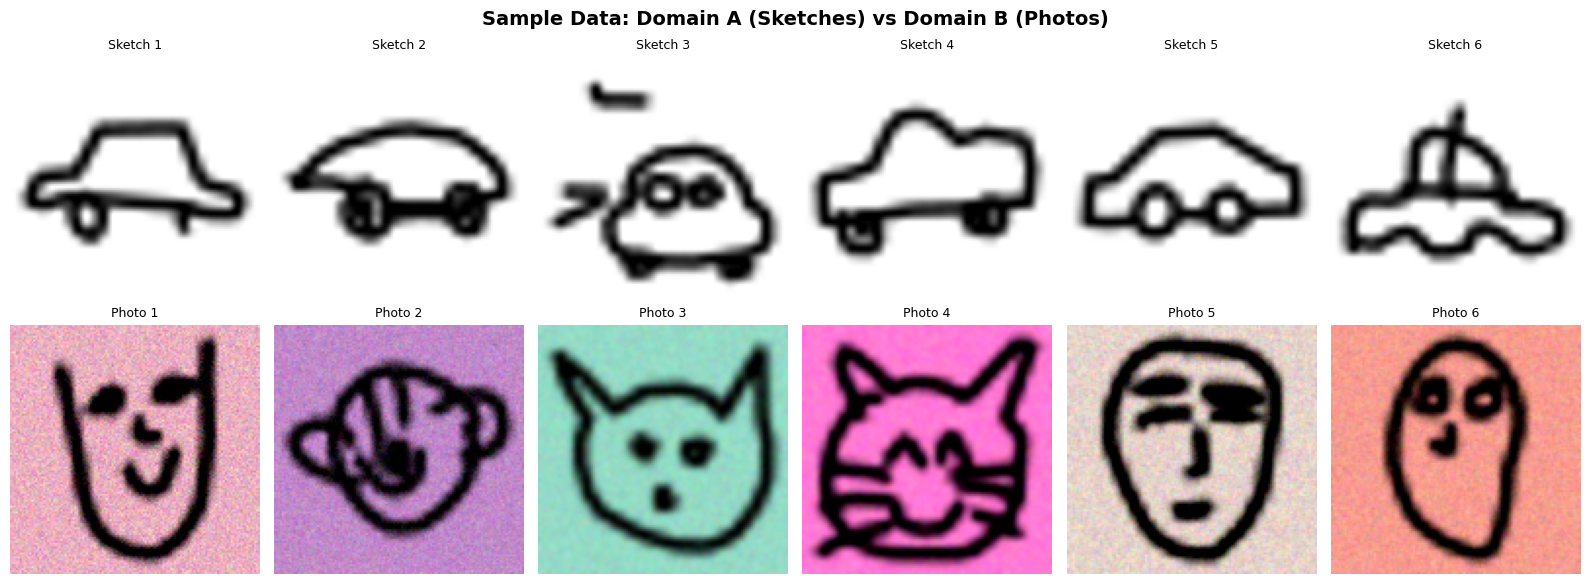

In [ ]:
# ─────────────────────────────────────────────────────────────────
# VISUALISE SAMPLE DATA
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Data: Domain A (Sketches) vs Domain B (Photos)', fontsize=14, fontweight='bold')

sketches = sorted(sketch_train_dir.iterdir())[:6]
photos   = sorted(photo_train_dir.iterdir())[:6]

for j, (sk, ph) in enumerate(zip(sketches, photos)):
    axes[0, j].imshow(Image.open(sk))
    axes[0, j].set_title(f'Sketch {j+1}', fontsize=9)
    axes[0, j].axis('off')
    axes[1, j].imshow(Image.open(ph))
    axes[1, j].set_title(f'Photo {j+1}', fontsize=9)
    axes[1, j].axis('off')

axes[0, 0].set_ylabel('Domain A\n(Sketches)', fontsize=10, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('Domain B\n(Photos)', fontsize=10, rotation=90, labelpad=10)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'sample_data.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 3: Dataset & DataLoader

In [ ]:
# ─────────────────────────────────────────────────────────────────
# TRANSFORMS
# ─────────────────────────────────────────────────────────────────

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16), transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # → [-1, 1]
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ─────────────────────────────────────────────────────────────────
# UNPAIRED DATASET
# ─────────────────────────────────────────────────────────────────

class UnpairedImageDataset(Dataset):
    """Loads images from two separate (unpaired) directories."""
    EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

    def __init__(self, dir_A, dir_B, transform=None):
        super().__init__()
        self.files_A   = sorted([f for f in Path(dir_A).iterdir() if f.suffix.lower() in self.EXTS])
        self.files_B   = sorted([f for f in Path(dir_B).iterdir() if f.suffix.lower() in self.EXTS])
        self.transform = transform
        self.len_A     = len(self.files_A)
        self.len_B     = len(self.files_B)

    def __len__(self):
        return max(self.len_A, self.len_B)

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        img_A = self._load(self.files_A[idx % self.len_A])
        # Random unpaired sample from B
        img_B = self._load(self.files_B[random.randint(0, self.len_B - 1)])
        return {'A': img_A, 'B': img_B}


train_dataset = UnpairedImageDataset(DATA_DIR/'trainA', DATA_DIR/'trainB', train_transform)
test_dataset  = UnpairedImageDataset(DATA_DIR/'testA',  DATA_DIR/'testB',  test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train samples: {len(train_dataset)} → {len(train_loader)} batches')
print(f'Test  samples: {len(test_dataset)}  → {len(test_loader)} batches')

# Quick shape check
batch = next(iter(train_loader))
print(f'   Batch shape A: {batch["A"].shape}  B: {batch["B"].shape}')
print(f'   Value range:   [{batch["A"].min():.2f}, {batch["A"].max():.2f}]')

Train samples: 2400 → 600 batches
Test  samples: 600  → 150 batches
   Batch shape A: torch.Size([4, 3, 128, 128])  B: torch.Size([4, 3, 128, 128])
   Value range:   [-1.00, 1.00]


## Section 4: Model Architecture

In [ ]:
# ─────────────────────────────────────────────────────────────────
# BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────

def weights_init_normal(m):
    """Initialise weights from N(0, 0.02) as in the original CycleGAN paper."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif 'BatchNorm2d' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class ResidualBlock(nn.Module):
    """ResNet residual block with Instance Normalisation."""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3, padding=0),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3, padding=0),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)   # skip connection


# ─────────────────────────────────────────────────────────────────
# GENERATOR  (ResNet-based)
# Architecture: c7s1-64 → d128 → d256 → R×6 → u128 → u64 → c7s1-3
# ─────────────────────────────────────────────────────────────────

class Generator(nn.Module):
    """
    CycleGAN ResNet Generator.
    img_channels : input/output channels (3 for RGB)
    n_res_blocks : number of ResNet blocks (6 for 128×128)
    """
    def __init__(self, img_channels=3, n_res_blocks=6, ngf=64):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────
        encoder = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(img_channels, ngf, kernel_size=7, padding=0),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),
        ]
        in_ch = ngf
        for _ in range(2):           # 2 down-sampling layers
            out_ch = in_ch * 2
            encoder += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch           # in_ch = 256 after 2 layers

        # ── Transformer (ResNet blocks) ──────────────────────────
        transformer = [ResidualBlock(in_ch) for _ in range(n_res_blocks)]

        # ── Decoder ──────────────────────────────────────────────
        decoder = []
        for _ in range(2):           # 2 up-sampling layers
            out_ch = in_ch // 2
            decoder += [
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=3, stride=2,
                                   padding=1, output_padding=1),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch

        decoder += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_ch, img_channels, kernel_size=7, padding=0),
            nn.Tanh(),
        ]

        self.model = nn.Sequential(*encoder, *transformer, *decoder)

    def forward(self, x):
        return self.model(x)


# ─────────────────────────────────────────────────────────────────
# DISCRIMINATOR  (PatchGAN)
# ─────────────────────────────────────────────────────────────────

class PatchDiscriminator(nn.Module):
    """
    70×70 PatchGAN Discriminator.
    Classifies overlapping image patches as real / fake.
    """
    def __init__(self, img_channels=3, ndf=64, n_layers=3):
        super().__init__()

        layers = [
            nn.Conv2d(img_channels, ndf, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
        ]

        in_ch = ndf
        for n in range(1, n_layers):
            out_ch = min(ndf * (2 ** n), 512)
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False),
                nn.InstanceNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True),
            ]
            in_ch = out_ch

        # Stride-1 layer
        out_ch = min(ndf * (2 ** n_layers), 512)
        layers += [
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        ]

        # Output patch map
        layers += [nn.Conv2d(out_ch, 1, kernel_size=4, stride=1, padding=1)]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# ─────────────────────────────────────────────────────────────────
# INSTANTIATE MODELS
# ─────────────────────────────────────────────────────────────────

G_AB = Generator(n_res_blocks=6).to(device)   # Sketch → Photo
G_BA = Generator(n_res_blocks=6).to(device)   # Photo  → Sketch
D_A  = PatchDiscriminator().to(device)         # Classifies Sketch domain
D_B  = PatchDiscriminator().to(device)         # Classifies Photo domain

# Apply initialisation
for model in [G_AB, G_BA, D_A, D_B]:
    model.apply(weights_init_normal)

# Parameter counts
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('Model Parameters:')
print(f'  G_AB (Sketch→Photo): {count_params(G_AB):,}')
print(f'  G_BA (Photo→Sketch): {count_params(G_BA):,}')
print(f'  D_A  (Sketch disc.): {count_params(D_A):,}')
print(f'  D_B  (Photo disc.):  {count_params(D_B):,}')

Model Parameters:
  G_AB (Sketch→Photo): 7,837,699
  G_BA (Photo→Sketch): 7,837,699
  D_A  (Sketch disc.): 2,763,841
  D_B  (Photo disc.):  2,763,841


## Section 5: Loss Functions & Optimisers

In [ ]:
# ─────────────────────────────────────────────────────────────────
# LOSS FUNCTIONS
# ─────────────────────────────────────────────────────────────────

criterion_GAN    = nn.MSELoss()    # Adversarial (LSGAN)
criterion_cycle  = nn.L1Loss()     # Cycle-consistency
criterion_identity = nn.L1Loss()   # Identity

LAMBDA_CYCLE    = 10.0   # weight for cycle-consistency loss
LAMBDA_IDENTITY = 5.0    # weight for identity loss  (= 0.5 * lambda_cycle)


# ─────────────────────────────────────────────────────────────────
# OPTIMISERS
# ─────────────────────────────────────────────────────────────────

LR         = 2e-4
BETAS      = (0.5, 0.999)
N_EPOCHS   = 30     # increase for better results
DECAY_EPOCH = 15    # start LR linear decay from this epoch

optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()),
    lr=LR, betas=BETAS
)
optimizer_D = torch.optim.Adam(
    itertools.chain(D_A.parameters(), D_B.parameters()),
    lr=LR, betas=BETAS
)


# ─────────────────────────────────────────────────────────────────
# LEARNING RATE SCHEDULER  (linear decay after DECAY_EPOCH)
# ─────────────────────────────────────────────────────────────────

def get_lr_lambda(current_epoch):
    if current_epoch < DECAY_EPOCH:
        return 1.0
    return max(0.0, 1.0 - (current_epoch - DECAY_EPOCH) / (N_EPOCHS - DECAY_EPOCH))

scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=get_lr_lambda)
scheduler_D = torch.optim.lr_scheduler.LambdaLR(optimizer_D, lr_lambda=get_lr_lambda)


# ─────────────────────────────────────────────────────────────────
# REPLAY BUFFER  (historical fake images to stabilise D training)
# ─────────────────────────────────────────────────────────────────

class ReplayBuffer:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.buffer   = []

    @torch.no_grad()
    def push_and_pop(self, images):
        results = []
        for image in images:
            image = image.unsqueeze(0)
            if len(self.buffer) < self.max_size:
                self.buffer.append(image)
                results.append(image)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.max_size - 1)
                    results.append(self.buffer[idx].clone())
                    self.buffer[idx] = image
                else:
                    results.append(image)
        return torch.cat(results, dim=0)


fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

# ─────────────────────────────────────────────────────────────────
# MIXED PRECISION SCALER
# ─────────────────────────────────────────────────────────────────

scaler_G = GradScaler()
scaler_D = GradScaler()

print('Losses, optimisers, schedulers and replay buffers ready')

Losses, optimisers, schedulers and replay buffers ready


/tmp/ipykernel_6611/2501674515.py:79: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = GradScaler()
/tmp/ipykernel_6611/2501674515.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = GradScaler()


## Section 6: Forward Pass (CycleGAN Pipeline)

Forward Pass Shapes:
  real_A  (Sketch):    torch.Size([4, 3, 128, 128])
  fake_B  (→Photo):    torch.Size([4, 3, 128, 128])
  recon_A (→Sketch):   torch.Size([4, 3, 128, 128])
  real_B  (Photo):     torch.Size([4, 3, 128, 128])
  fake_A  (→Sketch):   torch.Size([4, 3, 128, 128])
  recon_B (→Photo):    torch.Size([4, 3, 128, 128])


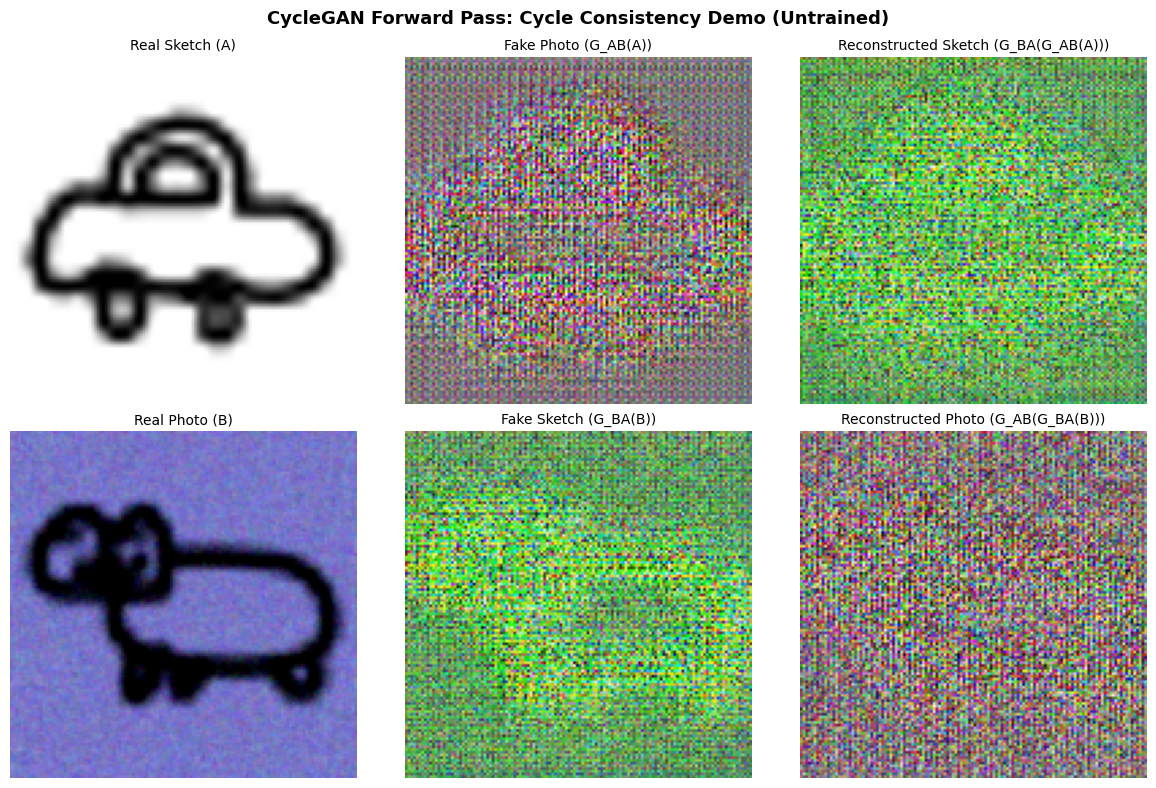

Forward pass complete


In [ ]:
# ─────────────────────────────────────────────────────────────────
# FORWARD PASS ILLUSTRATION  (single batch)
# ─────────────────────────────────────────────────────────────────

def denorm(tensor):
    """Convert [-1,1] tensor → [0,1] numpy image for display."""
    return ((tensor.detach().cpu().clamp(-1, 1) + 1) / 2).permute(1, 2, 0).numpy()


batch = next(iter(test_loader))
real_A = batch['A'].to(device)   # Sketches
real_B = batch['B'].to(device)   # Photos

G_AB.eval(); G_BA.eval()
with torch.no_grad():
    fake_B  = G_AB(real_A)          # Sketch → Photo
    recon_A = G_BA(fake_B)          # Photo  → Sketch  (cycle)
    fake_A  = G_BA(real_B)          # Photo  → Sketch
    recon_B = G_AB(fake_A)          # Sketch → Photo   (cycle)
    ident_A = G_BA(real_A)          # Identity: Sketch → Sketch
    ident_B = G_AB(real_B)          # Identity: Photo  → Photo

print('Forward Pass Shapes:')
print(f'  real_A  (Sketch):    {real_A.shape}')
print(f'  fake_B  (→Photo):    {fake_B.shape}')
print(f'  recon_A (→Sketch):   {recon_A.shape}')
print(f'  real_B  (Photo):     {real_B.shape}')
print(f'  fake_A  (→Sketch):   {fake_A.shape}')
print(f'  recon_B (→Photo):    {recon_B.shape}')

# ── Visualise the two cycles ──
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
titles = [
    ('Real Sketch (A)', 'Fake Photo (G_AB(A))', 'Reconstructed Sketch (G_BA(G_AB(A)))'),
    ('Real Photo (B)',  'Fake Sketch (G_BA(B))', 'Reconstructed Photo (G_AB(G_BA(B)))')
]
pairs = [
    (real_A[0], fake_B[0], recon_A[0]),
    (real_B[0], fake_A[0], recon_B[0]),
]

for row, (imgs, ttls) in enumerate(zip(pairs, titles)):
    for col, (img, title) in enumerate(zip(imgs, ttls)):
        axes[row, col].imshow(denorm(img))
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis('off')

fig.suptitle('CycleGAN Forward Pass: Cycle Consistency Demo (Untrained)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'forward_pass_untrained.png', dpi=120, bbox_inches='tight')
plt.show()

G_AB.train(); G_BA.train()
print('Forward pass complete')

## Section 7: Training Loop

In [ ]:
# ─────────────────────────────────────────────────────────────────
# TRAINING HISTORY
# ─────────────────────────────────────────────────────────────────

history = {
    'loss_G': [],   'loss_D': [],
    'loss_cycle': [], 'loss_identity': [],
    'loss_adv_G': [],
}


def save_checkpoint(epoch):
    torch.save({
        'epoch':        epoch,
        'G_AB':         G_AB.state_dict(),
        'G_BA':         G_BA.state_dict(),
        'D_A':          D_A.state_dict(),
        'D_B':          D_B.state_dict(),
        'optimizer_G':  optimizer_G.state_dict(),
        'optimizer_D':  optimizer_D.state_dict(),
        'history':      history,
    }, CKPT_DIR / f'checkpoint_epoch_{epoch:03d}.pth')


def load_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    G_AB.load_state_dict(ckpt['G_AB'])
    G_BA.load_state_dict(ckpt['G_BA'])
    D_A.load_state_dict(ckpt['D_A'])
    D_B.load_state_dict(ckpt['D_B'])
    optimizer_G.load_state_dict(ckpt['optimizer_G'])
    optimizer_D.load_state_dict(ckpt['optimizer_D'])
    return ckpt['epoch'], ckpt.get('history', history)


print(' Training infrastructure ready')

 Training infrastructure ready


In [14]:
# ─────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────

SAVE_EVERY  = 5     # save checkpoint every N epochs
VIS_EVERY   = 2     # visualise results every N epochs
start_epoch = 0

# ── Resume from checkpoint (optional) ────────────────────────────
latest_ckpt = sorted(CKPT_DIR.glob('checkpoint_epoch_*.pth'))
if latest_ckpt:
    print(f'Resuming from {latest_ckpt[-1].name}')
    start_epoch, history = load_checkpoint(latest_ckpt[-1])
    start_epoch += 1
# ─────────────────────────────────────────────────────────────────

print(f'Training for {N_EPOCHS} epochs starting at epoch {start_epoch}')
print(f'λ_cycle={LAMBDA_CYCLE}  λ_identity={LAMBDA_IDENTITY}  lr={LR}')
print('─' * 60)

for epoch in range(start_epoch, N_EPOCHS):
    G_AB.train(); G_BA.train(); D_A.train(); D_B.train()

    epoch_lG = epoch_lD = epoch_cyc = epoch_id = epoch_adv = 0.0
    t0 = time.time()

    for i, batch in enumerate(train_loader):
        real_A = batch['A'].to(device, non_blocking=True)
        real_B = batch['B'].to(device, non_blocking=True)
        bs     = real_A.size(0)

        # Target tensors for LSGAN
        valid_shape = D_A(real_A).shape
        ones  = torch.ones(valid_shape,  device=device)
        zeros = torch.zeros(valid_shape, device=device)

        #   ═════════════════════════════════════════
        #  ║  TRAIN GENERATORS                       ║
        #   ═════════════════════════════════════════
        optimizer_G.zero_grad(set_to_none=True)

        with autocast():
            # 1. Forward translations
            fake_B  = G_AB(real_A)     # Sketch → Photo
            fake_A  = G_BA(real_B)     # Photo  → Sketch

            # 2. Cycle-consistency
            recon_A = G_BA(fake_B)     # Photo  → Sketch
            recon_B = G_AB(fake_A)     # Sketch → Photo
            loss_cycle_A = criterion_cycle(recon_A, real_A)
            loss_cycle_B = criterion_cycle(recon_B, real_B)
            loss_cycle   = (loss_cycle_A + loss_cycle_B) * LAMBDA_CYCLE

            # 3. Identity loss
            ident_A  = G_BA(real_A)
            ident_B  = G_AB(real_B)
            loss_id  = (criterion_identity(ident_A, real_A) +
                        criterion_identity(ident_B, real_B)) * LAMBDA_IDENTITY

            # 4. Adversarial loss (fool the discriminators)
            loss_adv_AB = criterion_GAN(D_B(fake_B), ones)
            loss_adv_BA = criterion_GAN(D_A(fake_A), ones)
            loss_adv    = loss_adv_AB + loss_adv_BA

            loss_G = loss_adv + loss_cycle + loss_id

        scaler_G.scale(loss_G).backward()
        scaler_G.step(optimizer_G)
        scaler_G.update()

        #  ══════════════════════════════════════════
        # ║  TRAIN DISCRIMINATORS                    ║
        #  ══════════════════════════════════════════
        optimizer_D.zero_grad(set_to_none=True)

        with autocast():
            # Pull from replay buffer
            fake_A_hist = fake_A_buffer.push_and_pop(fake_A.detach())
            fake_B_hist = fake_B_buffer.push_and_pop(fake_B.detach())

            # D_A: real Sketch vs fake Sketch
            loss_DA_real = criterion_GAN(D_A(real_A), ones)
            loss_DA_fake = criterion_GAN(D_A(fake_A_hist), zeros)
            loss_DA      = (loss_DA_real + loss_DA_fake) * 0.5

            # D_B: real Photo vs fake Photo
            loss_DB_real = criterion_GAN(D_B(real_B), ones)
            loss_DB_fake = criterion_GAN(D_B(fake_B_hist), zeros)
            loss_DB      = (loss_DB_real + loss_DB_fake) * 0.5

            loss_D = loss_DA + loss_DB

        scaler_D.scale(loss_D).backward()
        scaler_D.step(optimizer_D)
        scaler_D.update()

        # Accumulate
        epoch_lG  += loss_G.item()
        epoch_lD  += loss_D.item()
        epoch_cyc += loss_cycle.item()
        epoch_id  += loss_id.item()
        epoch_adv += loss_adv.item()

    # ── Epoch-end bookkeeping ──────────────────────────────────────
    n_batches = len(train_loader)
    history['loss_G'].append(epoch_lG / n_batches)
    history['loss_D'].append(epoch_lD / n_batches)
    history['loss_cycle'].append(epoch_cyc / n_batches)
    history['loss_identity'].append(epoch_id / n_batches)
    history['loss_adv_G'].append(epoch_adv / n_batches)

    scheduler_G.step()
    scheduler_D.step()

    elapsed = time.time() - t0
    print(f'Epoch [{epoch+1:3d}/{N_EPOCHS}]  '
          f'G: {history["loss_G"][-1]:.4f}  '
          f'D: {history["loss_D"][-1]:.4f}  '
          f'Cycle: {history["loss_cycle"][-1]:.4f}  '
          f'ID: {history["loss_identity"][-1]:.4f}  '
          f'lr: {scheduler_G.get_last_lr()[0]:.6f}  '
          f't: {elapsed:.0f}s')

    if (epoch + 1) % SAVE_EVERY == 0 or epoch == N_EPOCHS - 1:
        save_checkpoint(epoch + 1)
        print(f'  Checkpoint saved at epoch {epoch+1}')

print('\nTraining complete!')

Training for 30 epochs starting at epoch 0
λ_cycle=10.0  λ_identity=5.0  lr=0.0002
────────────────────────────────────────────────────────────


/tmp/ipykernel_6611/328264877.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_6611/328264877.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [  1/30]  G: 5.8937  D: 0.7371  Cycle: 3.3868  ID: 1.5928  lr: 0.000200  t: 121s
Epoch [  2/30]  G: 5.0006  D: 0.4915  Cycle: 2.8971  ID: 1.3401  lr: 0.000200  t: 112s
Epoch [  3/30]  G: 4.4723  D: 0.4809  Cycle: 2.5417  ID: 1.1890  lr: 0.000200  t: 112s
Epoch [  4/30]  G: 4.1413  D: 0.4887  Cycle: 2.3565  ID: 1.0812  lr: 0.000200  t: 112s
Epoch [  5/30]  G: 3.6182  D: 0.5210  Cycle: 2.1199  ID: 0.9005  lr: 0.000200  t: 112s
  Checkpoint saved at epoch 5
Epoch [  6/30]  G: 3.3743  D: 0.4998  Cycle: 1.9004  ID: 0.8498  lr: 0.000200  t: 112s
Epoch [  7/30]  G: 3.1538  D: 0.5044  Cycle: 1.7524  ID: 0.7971  lr: 0.000200  t: 112s
Epoch [  8/30]  G: 3.0664  D: 0.5049  Cycle: 1.7116  ID: 0.7665  lr: 0.000200  t: 111s
Epoch [  9/30]  G: 2.9227  D: 0.5006  Cycle: 1.6250  ID: 0.7267  lr: 0.000200  t: 112s
Epoch [ 10/30]  G: 2.9552  D: 0.5013  Cycle: 1.6347  ID: 0.7328  lr: 0.000200  t: 112s
  Checkpoint saved at epoch 10
Epoch [ 11/30]  G: 2.9542  D: 0.4983  Cycle: 1.6313  ID: 0.7279  lr: 

## Section 8: Training Loss Plots

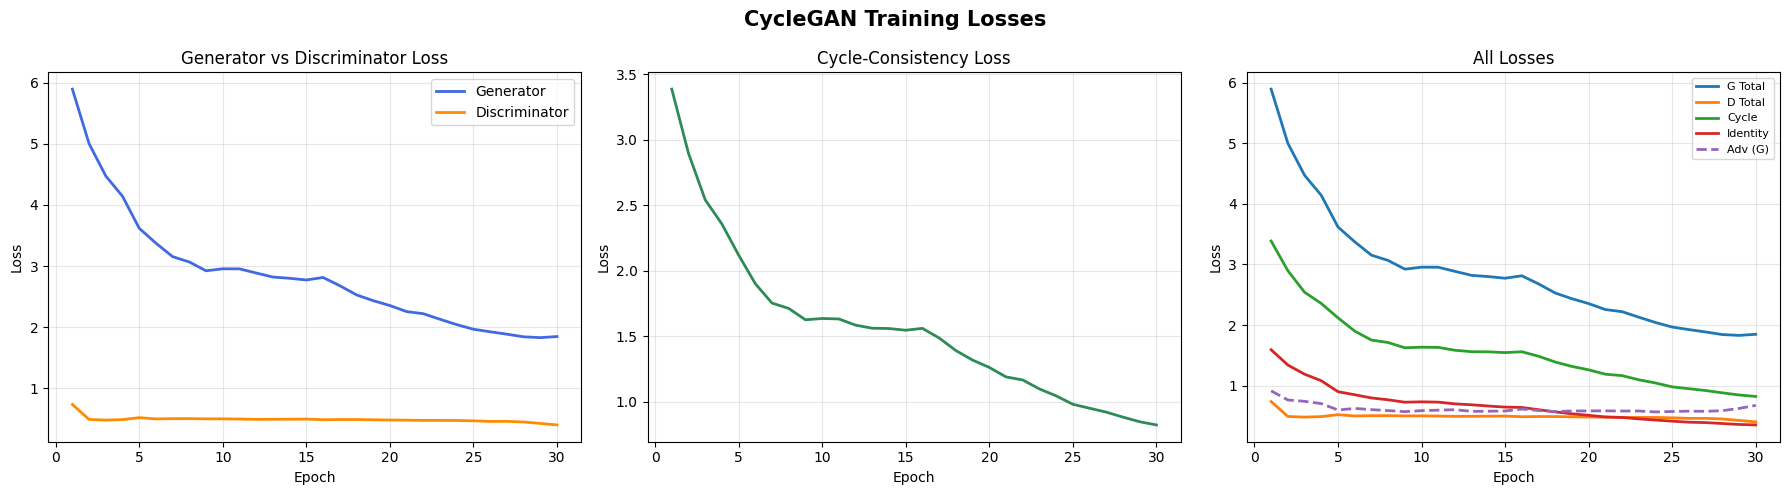

✅ Loss plots saved


In [15]:
# ─────────────────────────────────────────────────────────────────
# TRAINING LOSS PLOTS
# ─────────────────────────────────────────────────────────────────

epochs_x = range(1, len(history['loss_G']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CycleGAN Training Losses', fontsize=15, fontweight='bold')

# Plot 1 – Generator vs Discriminator
axes[0].plot(epochs_x, history['loss_G'], label='Generator',     color='royalblue',  lw=2)
axes[0].plot(epochs_x, history['loss_D'], label='Discriminator', color='darkorange',  lw=2)
axes[0].set_title('Generator vs Discriminator Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2 – Cycle-Consistency
axes[1].plot(epochs_x, history['loss_cycle'], color='seagreen', lw=2)
axes[1].set_title('Cycle-Consistency Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)

# Plot 3 – All losses
axes[2].plot(epochs_x, history['loss_G'],        label='G Total',    lw=2)
axes[2].plot(epochs_x, history['loss_D'],        label='D Total',    lw=2)
axes[2].plot(epochs_x, history['loss_cycle'],    label='Cycle',      lw=2)
axes[2].plot(epochs_x, history['loss_identity'], label='Identity',   lw=2)
axes[2].plot(epochs_x, history['loss_adv_G'],    label='Adv (G)',    lw=2, ls='--')
axes[2].set_title('All Losses')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / 'training_losses.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss plots saved')

## Section 9: Visualisation – Qualitative Results

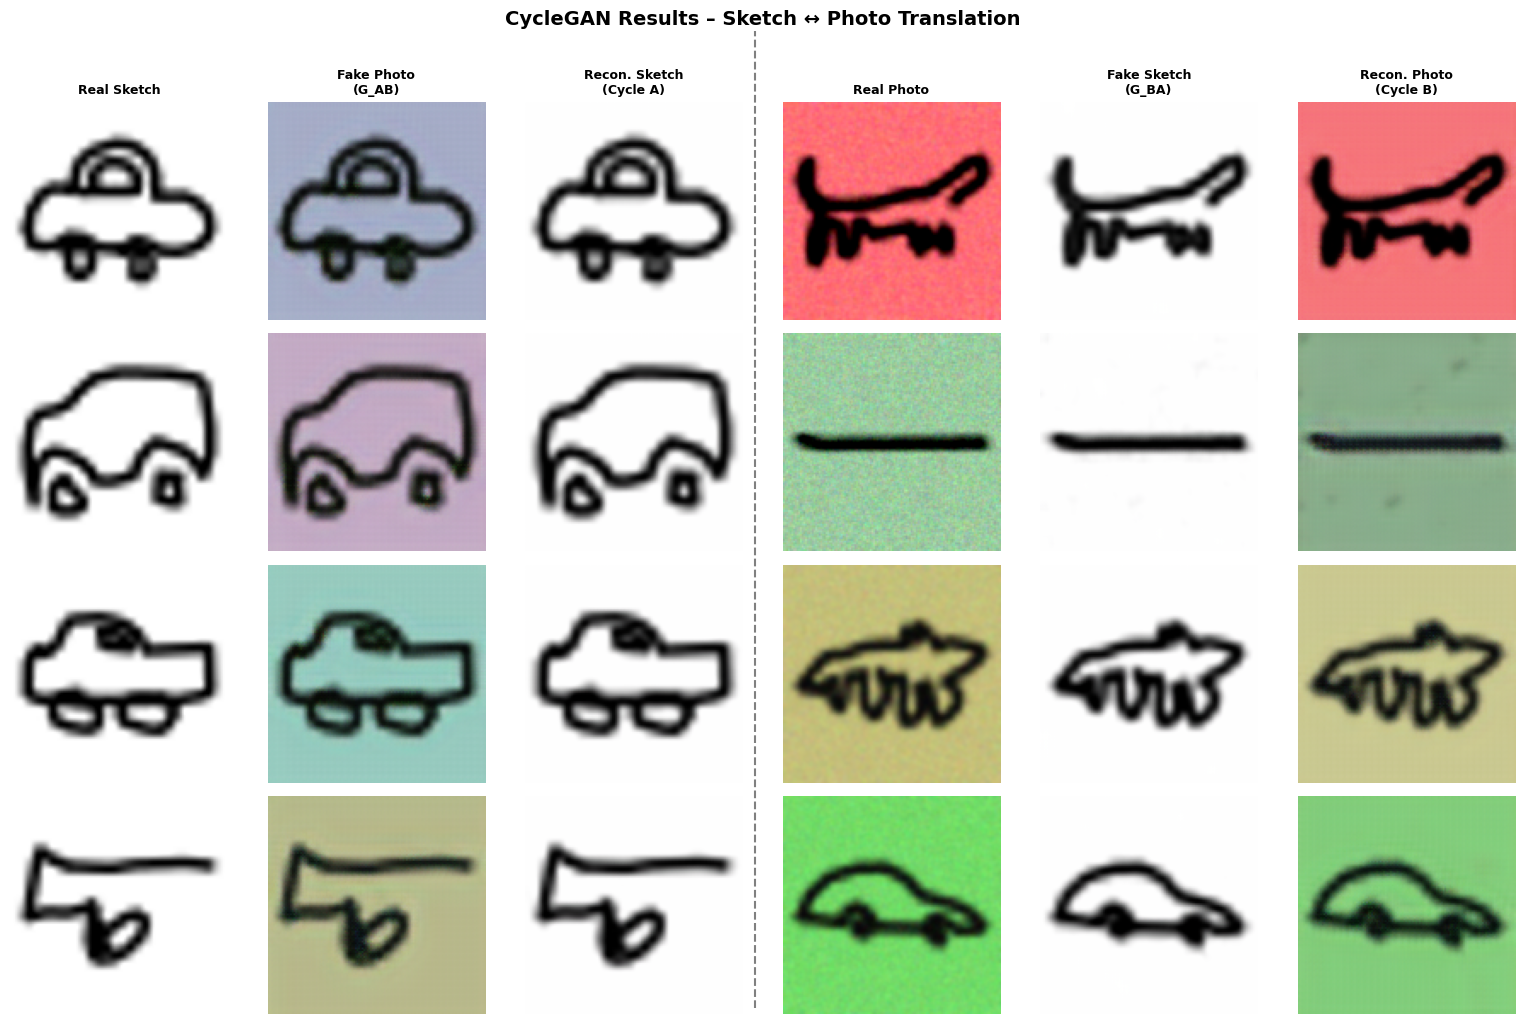

Qualitative results saved


In [23]:
# ─────────────────────────────────────────────────────────────────
# QUALITATIVE VISUALISATION  (≥ 5 examples)
# ─────────────────────────────────────────────────────────────────

def visualize_results(n_examples=5, save_path=None):
    G_AB.eval(); G_BA.eval()
    test_iter = iter(test_loader)
    batch = next(test_iter)

    # Ensure n_examples does not exceed the actual batch size
    n_actual_examples = min(n_examples, batch['A'].size(0))

    real_A = batch['A'][:n_actual_examples].to(device)
    real_B = batch['B'][:n_actual_examples].to(device)

    with torch.no_grad():
        fake_B  = G_AB(real_A)   # Sketch → Photo
        recon_A = G_BA(fake_B)   # Photo  → Sketch (cycle)
        fake_A  = G_BA(real_B)   # Photo  → Sketch
        recon_B = G_AB(fake_A)   # Sketch → Photo  (cycle)

    rows   = n_actual_examples # Use the actual number of examples
    cols   = 6
    labels = ['Real Sketch', 'Fake Photo\n(G_AB)', 'Recon. Sketch\n(Cycle A)',
              'Real Photo',  'Fake Sketch\n(G_BA)', 'Recon. Photo\n(Cycle B)']

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.6))
    fig.suptitle('CycleGAN Results – Sketch ↔ Photo Translation', fontsize=14, fontweight='bold')

    for r in range(rows):
        imgs = [real_A[r], fake_B[r], recon_A[r],
                real_B[r], fake_A[r], recon_B[r]]
        for c, (img, lbl) in enumerate(zip(imgs, labels)):
            ax = axes[r, c]
            ax.imshow(denorm(img))
            ax.axis('off')
            if r == 0:
                ax.set_title(lbl, fontsize=9, fontweight='bold')

    # Column separators
    fig.add_artist(plt.Line2D([0.495, 0.495], [0.02, 0.96],
                               transform=fig.transFigure,
                               color='grey', lw=1.5, ls='--'))

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    G_AB.train(); G_BA.train()


visualize_results(n_examples=5, save_path=RESULT_DIR / 'qualitative_results.png')
print('Qualitative results saved')

## Section 10: Quantitative Evaluation (SSIM & PSNR)

In [24]:
# ─────────────────────────────────────────────────────────────────
# SSIM & PSNR EVALUATION
# ─────────────────────────────────────────────────────────────────

def tensor_to_np_uint8(t):
    """Convert [-1,1] tensor (C,H,W) → (H,W,C) uint8 numpy."""
    arr = ((t.detach().cpu().clamp(-1, 1) + 1) / 2 * 255).permute(1, 2, 0).numpy().astype(np.uint8)
    return arr


def evaluate_metrics(loader, n_batches=10):
    G_AB.eval(); G_BA.eval()

    ssim_A, psnr_A = [], []   # Real A vs Recon A
    ssim_B, psnr_B = [], []   # Real B vs Recon B

    with torch.no_grad():
        for k, batch in enumerate(loader):
            if k >= n_batches:
                break
            real_A = batch['A'].to(device)
            real_B = batch['B'].to(device)

            fake_B  = G_AB(real_A)
            recon_A = G_BA(fake_B)
            fake_A  = G_BA(real_B)
            recon_B = G_AB(fake_A)

            for j in range(real_A.size(0)):
                ra = tensor_to_np_uint8(real_A[j])
                rc = tensor_to_np_uint8(recon_A[j])
                rb = tensor_to_np_uint8(real_B[j])
                rd = tensor_to_np_uint8(recon_B[j])

                ssim_A.append(ssim_fn(ra, rc, channel_axis=-1, data_range=255))
                psnr_A.append(psnr_fn(ra, rc, data_range=255))
                ssim_B.append(ssim_fn(rb, rd, channel_axis=-1, data_range=255))
                psnr_B.append(psnr_fn(rb, rd, data_range=255))

    return {
        'SSIM_cycle_A': np.mean(ssim_A), 'PSNR_cycle_A': np.mean(psnr_A),
        'SSIM_cycle_B': np.mean(ssim_B), 'PSNR_cycle_B': np.mean(psnr_B),
        'SSIM_avg':     (np.mean(ssim_A) + np.mean(ssim_B)) / 2,
        'PSNR_avg':     (np.mean(psnr_A) + np.mean(psnr_B)) / 2,
    }


metrics = evaluate_metrics(test_loader)

print('\nQuantitative Evaluation Metrics')
print('═' * 45)
print(f'  Cycle A (Real Sketch ↔ Recon Sketch):')
print(f'    SSIM: {metrics["SSIM_cycle_A"]:.4f}   PSNR: {metrics["PSNR_cycle_A"]:.2f} dB')
print(f'  Cycle B (Real Photo ↔ Recon Photo):')
print(f'    SSIM: {metrics["SSIM_cycle_B"]:.4f}   PSNR: {metrics["PSNR_cycle_B"]:.2f} dB')
print(f'  Overall Average:')
print(f'    SSIM: {metrics["SSIM_avg"]:.4f}   PSNR: {metrics["PSNR_avg"]:.2f} dB')
print('═' * 45)

# Save metrics to JSON
with open(RESULT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

G_AB.train(); G_BA.train()
print('Metrics saved')


Quantitative Evaluation Metrics
═════════════════════════════════════════════
  Cycle A (Real Sketch ↔ Recon Sketch):
    SSIM: 0.9943   PSNR: 35.51 dB
  Cycle B (Real Photo ↔ Recon Photo):
    SSIM: 0.6738   PSNR: 23.94 dB
  Overall Average:
    SSIM: 0.8341   PSNR: 29.72 dB
═════════════════════════════════════════════
Metrics saved


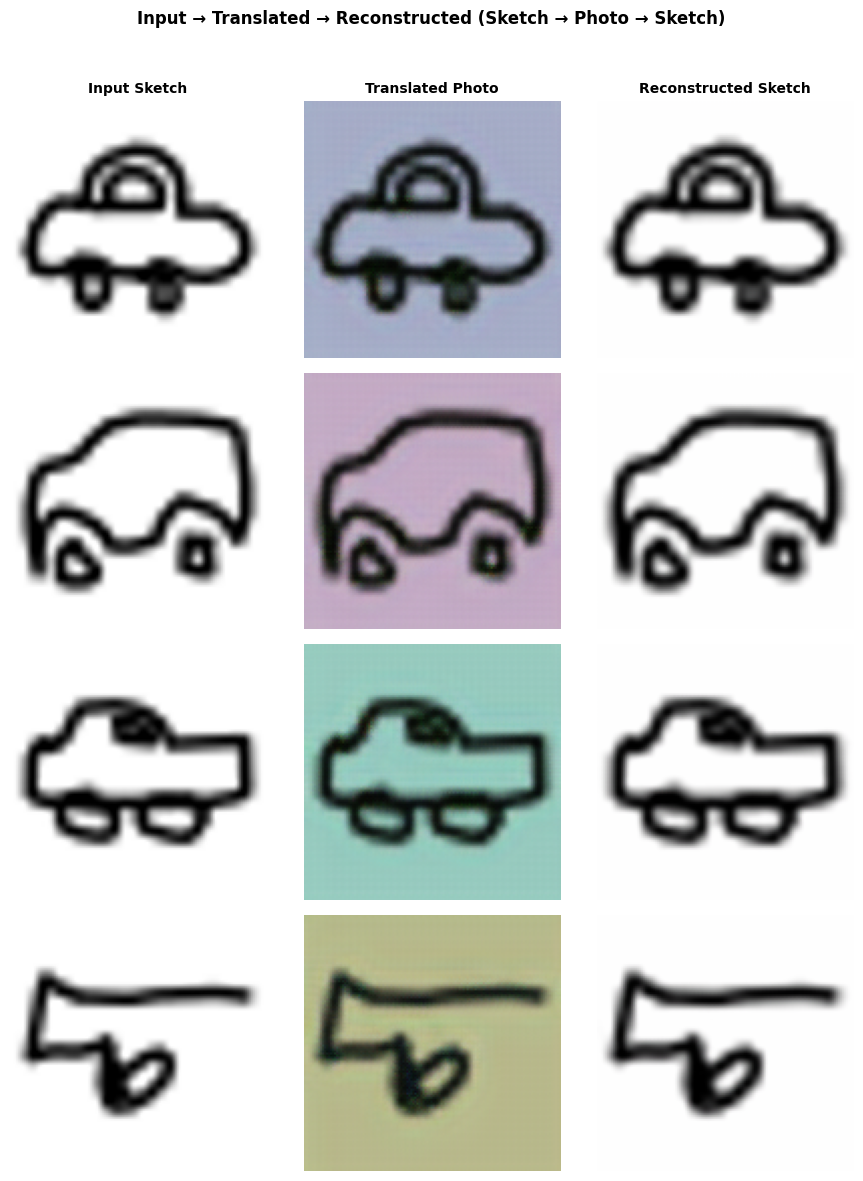

Generator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): ReLU(inplace=True)
        (4): ReflectionPad2d((1, 1, 1, 1))
        (5): C

In [25]:
# ─────────────────────────────────────────────────────────────────
# VISUAL COMPARISON: Input → Translated → Reconstructed
# ─────────────────────────────────────────────────────────────────

G_AB.eval(); G_BA.eval()
batch = next(iter(test_loader))
n = min(5, batch['A'].size(0))
real_A = batch['A'][:n].to(device)
real_B = batch['B'][:n].to(device)

with torch.no_grad():
    fake_B  = G_AB(real_A)
    recon_A = G_BA(fake_B)

fig, axes = plt.subplots(n, 3, figsize=(9, n * 3))
fig.suptitle('Input → Translated → Reconstructed (Sketch → Photo → Sketch)',
             fontsize=12, fontweight='bold')

for r in range(n):
    for c, (img, title) in enumerate([
        (real_A[r], 'Input Sketch'),
        (fake_B[r], 'Translated Photo'),
        (recon_A[r],'Reconstructed Sketch'),
    ]):
        axes[r, c].imshow(denorm(img))
        axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(RESULT_DIR / 'input_translated_reconstructed.png', dpi=120, bbox_inches='tight')
plt.show()
G_AB.train(); G_BA.train()

## Section 11: Gradio App Deployment

In [26]:
!pip install -q gradio
import gradio as gr
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as T

print(f'Gradio version: {gr.__version__}')

Gradio version: 5.50.0


In [27]:
# ─────────────────────────────────────────────────────────────────
# GRADIO APP
# ─────────────────────────────────────────────────────────────────

# Load best checkpoint
ckpts = sorted(CKPT_DIR.glob('checkpoint_epoch_*.pth'))
if ckpts:
    load_checkpoint(ckpts[-1])
    print(f'Loaded {ckpts[-1].name} for inference')

G_AB.eval()
G_BA.eval()


infer_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])


def pil_to_tensor(img):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return infer_tf(img).unsqueeze(0).to(device)


def tensor_to_pil(t):
    arr = ((t.squeeze(0).detach().cpu().clamp(-1, 1) + 1) / 2 * 255)
    return Image.fromarray(arr.permute(1, 2, 0).numpy().astype(np.uint8))


def translate(input_image, direction):
    """Translate input image in the specified direction."""
    if input_image is None:
        return None, 'Please upload an image.'

    pil = Image.fromarray(input_image)
    tensor = pil_to_tensor(pil)

    with torch.no_grad():
        if direction == 'Sketch → Photo  (G_AB)':
            out = G_AB(tensor)
            label = 'Generated Photo'
        else:
            out = G_BA(tensor)
            label = 'Generated Sketch'

    out_pil = tensor_to_pil(out)
    info = f'✅ Translation complete: {direction}\nOutput size: {out_pil.size}'
    return np.array(out_pil), info


with gr.Blocks(title='CycleGAN – Sketch ↔ Photo', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🎨 CycleGAN – Sketch ↔ Photo Domain Translation
    Upload an image and choose the translation direction.
    The model performs **unpaired** image-to-image translation using a CycleGAN.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            input_img = gr.Image(label='Input Image', type='numpy', height=300)
            direction = gr.Radio(
                choices=['Sketch → Photo  (G_AB)', 'Photo → Sketch  (G_BA)'],
                value='Sketch → Photo  (G_AB)',
                label='Translation Direction'
            )
            translate_btn = gr.Button('🔄 Translate', variant='primary')

        with gr.Column(scale=1):
            output_img  = gr.Image(label='Translated Output', height=300)
            status_text = gr.Textbox(label='Status', lines=2)

    translate_btn.click(
        fn=translate,
        inputs=[input_img, direction],
        outputs=[output_img, status_text]
    )

    gr.Markdown("""
    ---
    **Model Details:**
    Generator: ResNet-6 blocks | Discriminator: PatchGAN | Image size: 128×128
    Losses: Adversarial (LSGAN) + Cycle-consistency (λ=10) + Identity (λ=5)
    """)

demo.launch(share=True, debug=False)
print('✅ Gradio app launched')

Loaded checkpoint_epoch_030.pth for inference


/tmp/ipykernel_6611/1720366662.py:54: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='CycleGAN – Sketch ↔ Photo', theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1335b2fae45a38f841.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Gradio app launched
